In [1]:
from pathlib import Path


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in (start, *start.parents):
        if (path / "data" / "loader_roots").exists():
            return path
    raise FileNotFoundError("Could not find data/loader_roots from the current working directory.")


PROJECT_ROOT = find_project_root()
XJTU_ROOT = str(PROJECT_ROOT / "data" / "loader_roots" / "xjtu")
PHM2012_ROOT = str(PROJECT_ROOT / "data" / "loader_roots" / "phm2012")

import torch
from torch import nn

from phm.data import Dataset
from phm.data.labeler.BearingFaultLabeler import BearingFaultLabeler
from phm.data.loader.XJTULoader import XJTULoader, Fault
from phm.data.process.EntityPipeline import EntityPipeline
from phm.data.process.array.RMSProcessor import RMSProcessor
from phm.engine.Evaluator import Evaluator
from phm.engine.metric.Accuracy import Accuracy
from phm.engine.metric.WeightedF1Score import WeightedF1Score
from phm.data.process.entity.ThreeSigmaFPTCalculator import ThreeSigmaFPTCalculator
from phm.engine.tester.BaseTester import BaseTester
from phm.engine.trainer.BaseTrainer import BaseTrainer
from phm.engine.callback.CheckGradientsCallback import CheckGradientsCallback
from phm.engine.callback.EarlyStoppingCallback import EarlyStoppingCallback
from phm.engine.callback.TensorBoardCallback import TensorBoardCallback
from phm.model.basic.CNN import CNN
from phm.util.Cache import Cache
from phm.util.Plotter import Plotter
from phm.util.Device import select_torch_device


In [2]:
cache_dataset = True
# cache_dataset = False
# cache_model = True
cache_model = False

fault_types = [Fault.NC, Fault.OF, Fault.IF, Fault.CF]

# 获取数据集

In [3]:
dataset = Cache.load('diagnosis_dataset', is_able=cache_dataset)
if dataset is None:
    data_loader = XJTULoader(XJTU_ROOT)
    labeler = BearingFaultLabeler(2048, fault_types, is_multi_hot=False, is_from_fpt=False)
    pipeline = EntityPipeline()
    pipeline.register(
        processor=RMSProcessor(data_loader['continuum']),
        input_key='Horizontal Vibration',
        output_key='RMS'
    )
    pipeline.register(
        processor=ThreeSigmaFPTCalculator(),
        input_key='RMS',
    )

    # 通过其他轴承增加训练数据
    dataset = Dataset()
    for bearing_name in ['Bearing1_1', 'Bearing1_2', "Bearing1_3",
                         'Bearing2_3', 'Bearing2_2', 'Bearing2_4', 'Bearing2_5',
                         'Bearing3_3']:
        bearing = data_loader(bearing_name, include='Horizontal Vibration')
        pipeline.execute(bearing)
        dataset.append_entity(labeler(bearing, 'Horizontal Vibration'))
    Cache.save(dataset, 'diagnosis_dataset')

[INFO    22:04:26]  [Cache]  Cache miss: cache/diagnosis_dataset.pkl
[DEBUG   22:04:26]  
[DataLoader]  Root directory: /Users/nev8r/Desktop/phm2/data/loader_roots/xjtu
	- Bearing1_1, location: /Users/nev8r/Desktop/phm2/data/loader_roots/xjtu/35Hz12kN/Bearing1_1
	- Bearing1_5, location: /Users/nev8r/Desktop/phm2/data/loader_roots/xjtu/35Hz12kN/Bearing1_5
	- Bearing1_2, location: /Users/nev8r/Desktop/phm2/data/loader_roots/xjtu/35Hz12kN/Bearing1_2
	- Bearing1_3, location: /Users/nev8r/Desktop/phm2/data/loader_roots/xjtu/35Hz12kN/Bearing1_3
	- Bearing1_4, location: /Users/nev8r/Desktop/phm2/data/loader_roots/xjtu/35Hz12kN/Bearing1_4
	- Bearing2_1, location: /Users/nev8r/Desktop/phm2/data/loader_roots/xjtu/37.5Hz11kN/Bearing2_1
	- Bearing2_5, location: /Users/nev8r/Desktop/phm2/data/loader_roots/xjtu/37.5Hz11kN/Bearing2_5
	- Bearing2_2, location: /Users/nev8r/Desktop/phm2/data/loader_roots/xjtu/37.5Hz11kN/Bearing2_2
	- Bearing2_3, location: /Users/nev8r/Desktop/phm2/data/loader_roots/xjtu

# 划分数据集：训练集（70%）、验证集（15%）、测试集（15%）
- 训练集：用于模型参数学习
- 验证集：用于模型调参、早停（early stopping）、选择最佳模型
- 测试集：只用于最终性能评估，不参与任何训练和调参过程

In [4]:
train_set, test_set = dataset.split_by_ratio(0.7)
val_set, test_set = test_set.split_by_ratio(0.5)

[INFO    22:04:39]  [Dataset]  Splitting data by ratio 0.7 using random seed: 222192175117228741985690443662776030713
[INFO    22:04:39]  [Dataset]  Splitting data by ratio 0.5 using random seed: 180596867963212608855005156332452465946


# 配置测试算法

In [5]:
tester = BaseTester()

# 配置训练算法

In [6]:
train_config = {
    'device': select_torch_device(),
    'dtype': torch.float32,
    'epochs': 10,
    'batch_size': 128,
    'lr': 0.001,
    'weight_decay': 0.0,
    'criterion': nn.CrossEntropyLoss(),
    'callbacks': [
        EarlyStoppingCallback(patience=20,
                              val_set=test_set,
                              metric=Accuracy(),
                              tester=tester),
        TensorBoardCallback(),
        CheckGradientsCallback()
    ]
}
trainer = BaseTrainer(config=train_config)

# 定义模型并训练

[INFO    22:04:40]  
[Trainer]  Start training by BaseTrainer:
	training set: Bearing1_1; Bearing1_2; Bearing1_3;…
	device: mps
	dtype: torch.float32
	epochs: 10
	batch_size: 128
	lr: 0.001
	weight_decay: 0.0
	criterion: CrossEntropyLoss()
	callbacks: [EarlyStoppingCallback, TensorBoardCallback, CheckGradientsCallback]
	optimizer: Adam
[DEBUG   22:04:41]  [EarlyStopping]  On the validation set Bearing1_1; Bearing1_2; Bearing1_3; Bearing2_3; Bearing2_2; Bearing2_4; Bearing2_5; Bearing3_3, the Accuracy is 0.5578
[INFO    22:04:45]  [BaseTrainer]  Epoch [1/10], CrossEntropyLoss:0.3987
[DEBUG   22:04:45]  [EarlyStopping]  On the validation set Bearing1_1; Bearing1_2; Bearing1_3; Bearing2_3; Bearing2_2; Bearing2_4; Bearing2_5; Bearing3_3, the Accuracy is 0.9601
[INFO    22:04:49]  [BaseTrainer]  Epoch [2/10], CrossEntropyLoss:0.1020
[DEBUG   22:04:49]  [EarlyStopping]  On the validation set Bearing1_1; Bearing1_2; Bearing1_3; Bearing2_3; Bearing2_2; Bearing2_4; Bearing2_5; Bearing3_3, the A

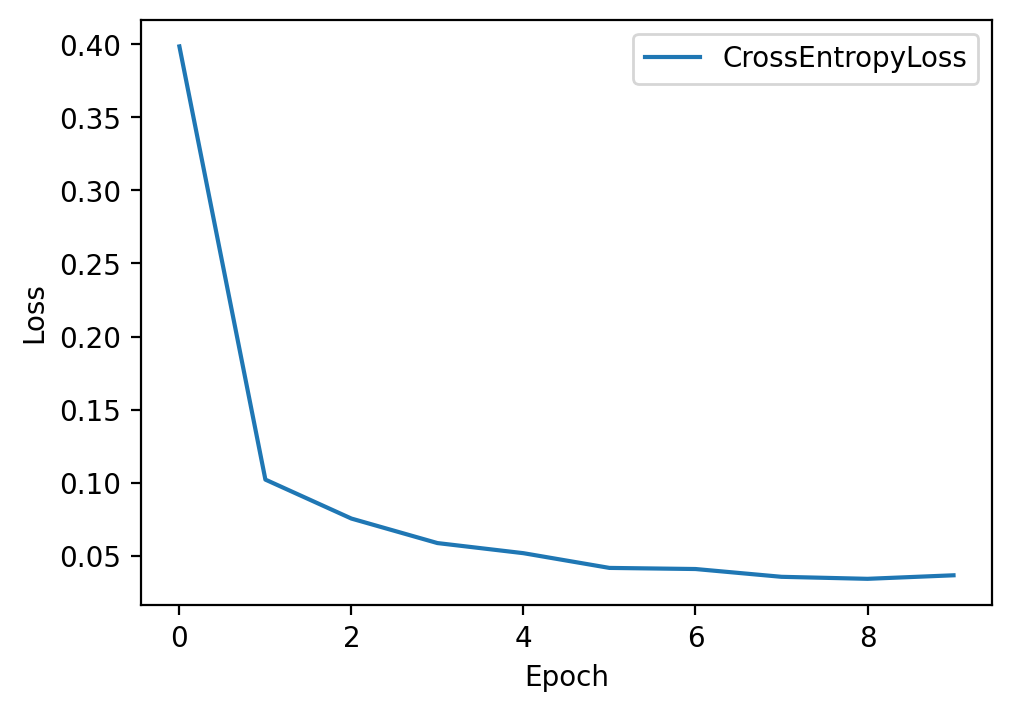

[DEBUG   22:05:03]  [Cache]  Generating cache file: cache/diagnosis_model.pkl
[DEBUG   22:05:03]  [Cache]  Generated cache file: cache/diagnosis_model.pkl


In [7]:
model = Cache.load('diagnosis_model', cache_model)
if model is None:
    model = CNN(2048, len(fault_types))
    # 配置训练算法
    # 开始训练
    losses = trainer.train(model=model, train_set=train_set)
    Plotter.loss(losses)
    Cache.save(model, 'diagnosis_model')

# 测试

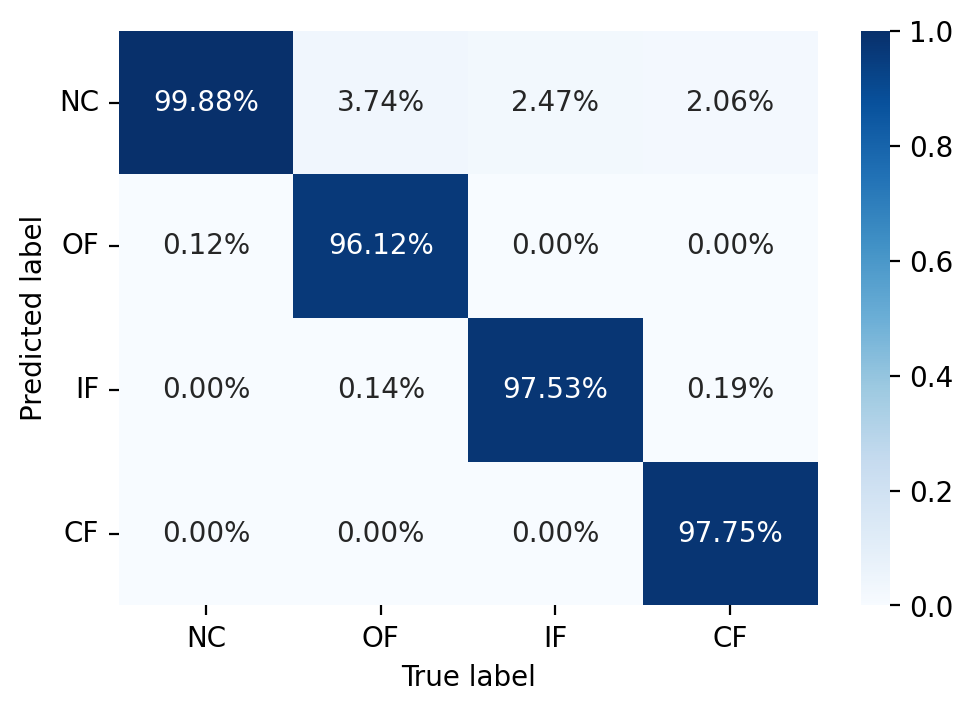

In [8]:
result = tester.test(model, test_set)
Plotter.confusion_matrix(test_set, result, types=fault_types)

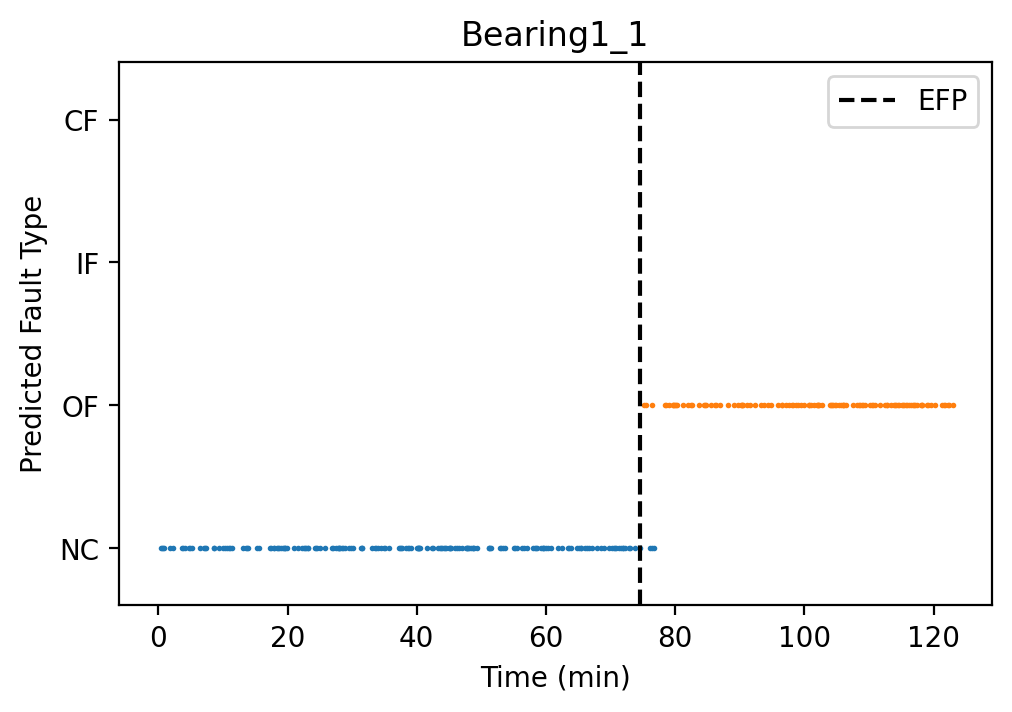

In [9]:
Plotter.fault_evolution(test_set.get('Bearing1_1'), result.get('Bearing1_1'), types=fault_types)

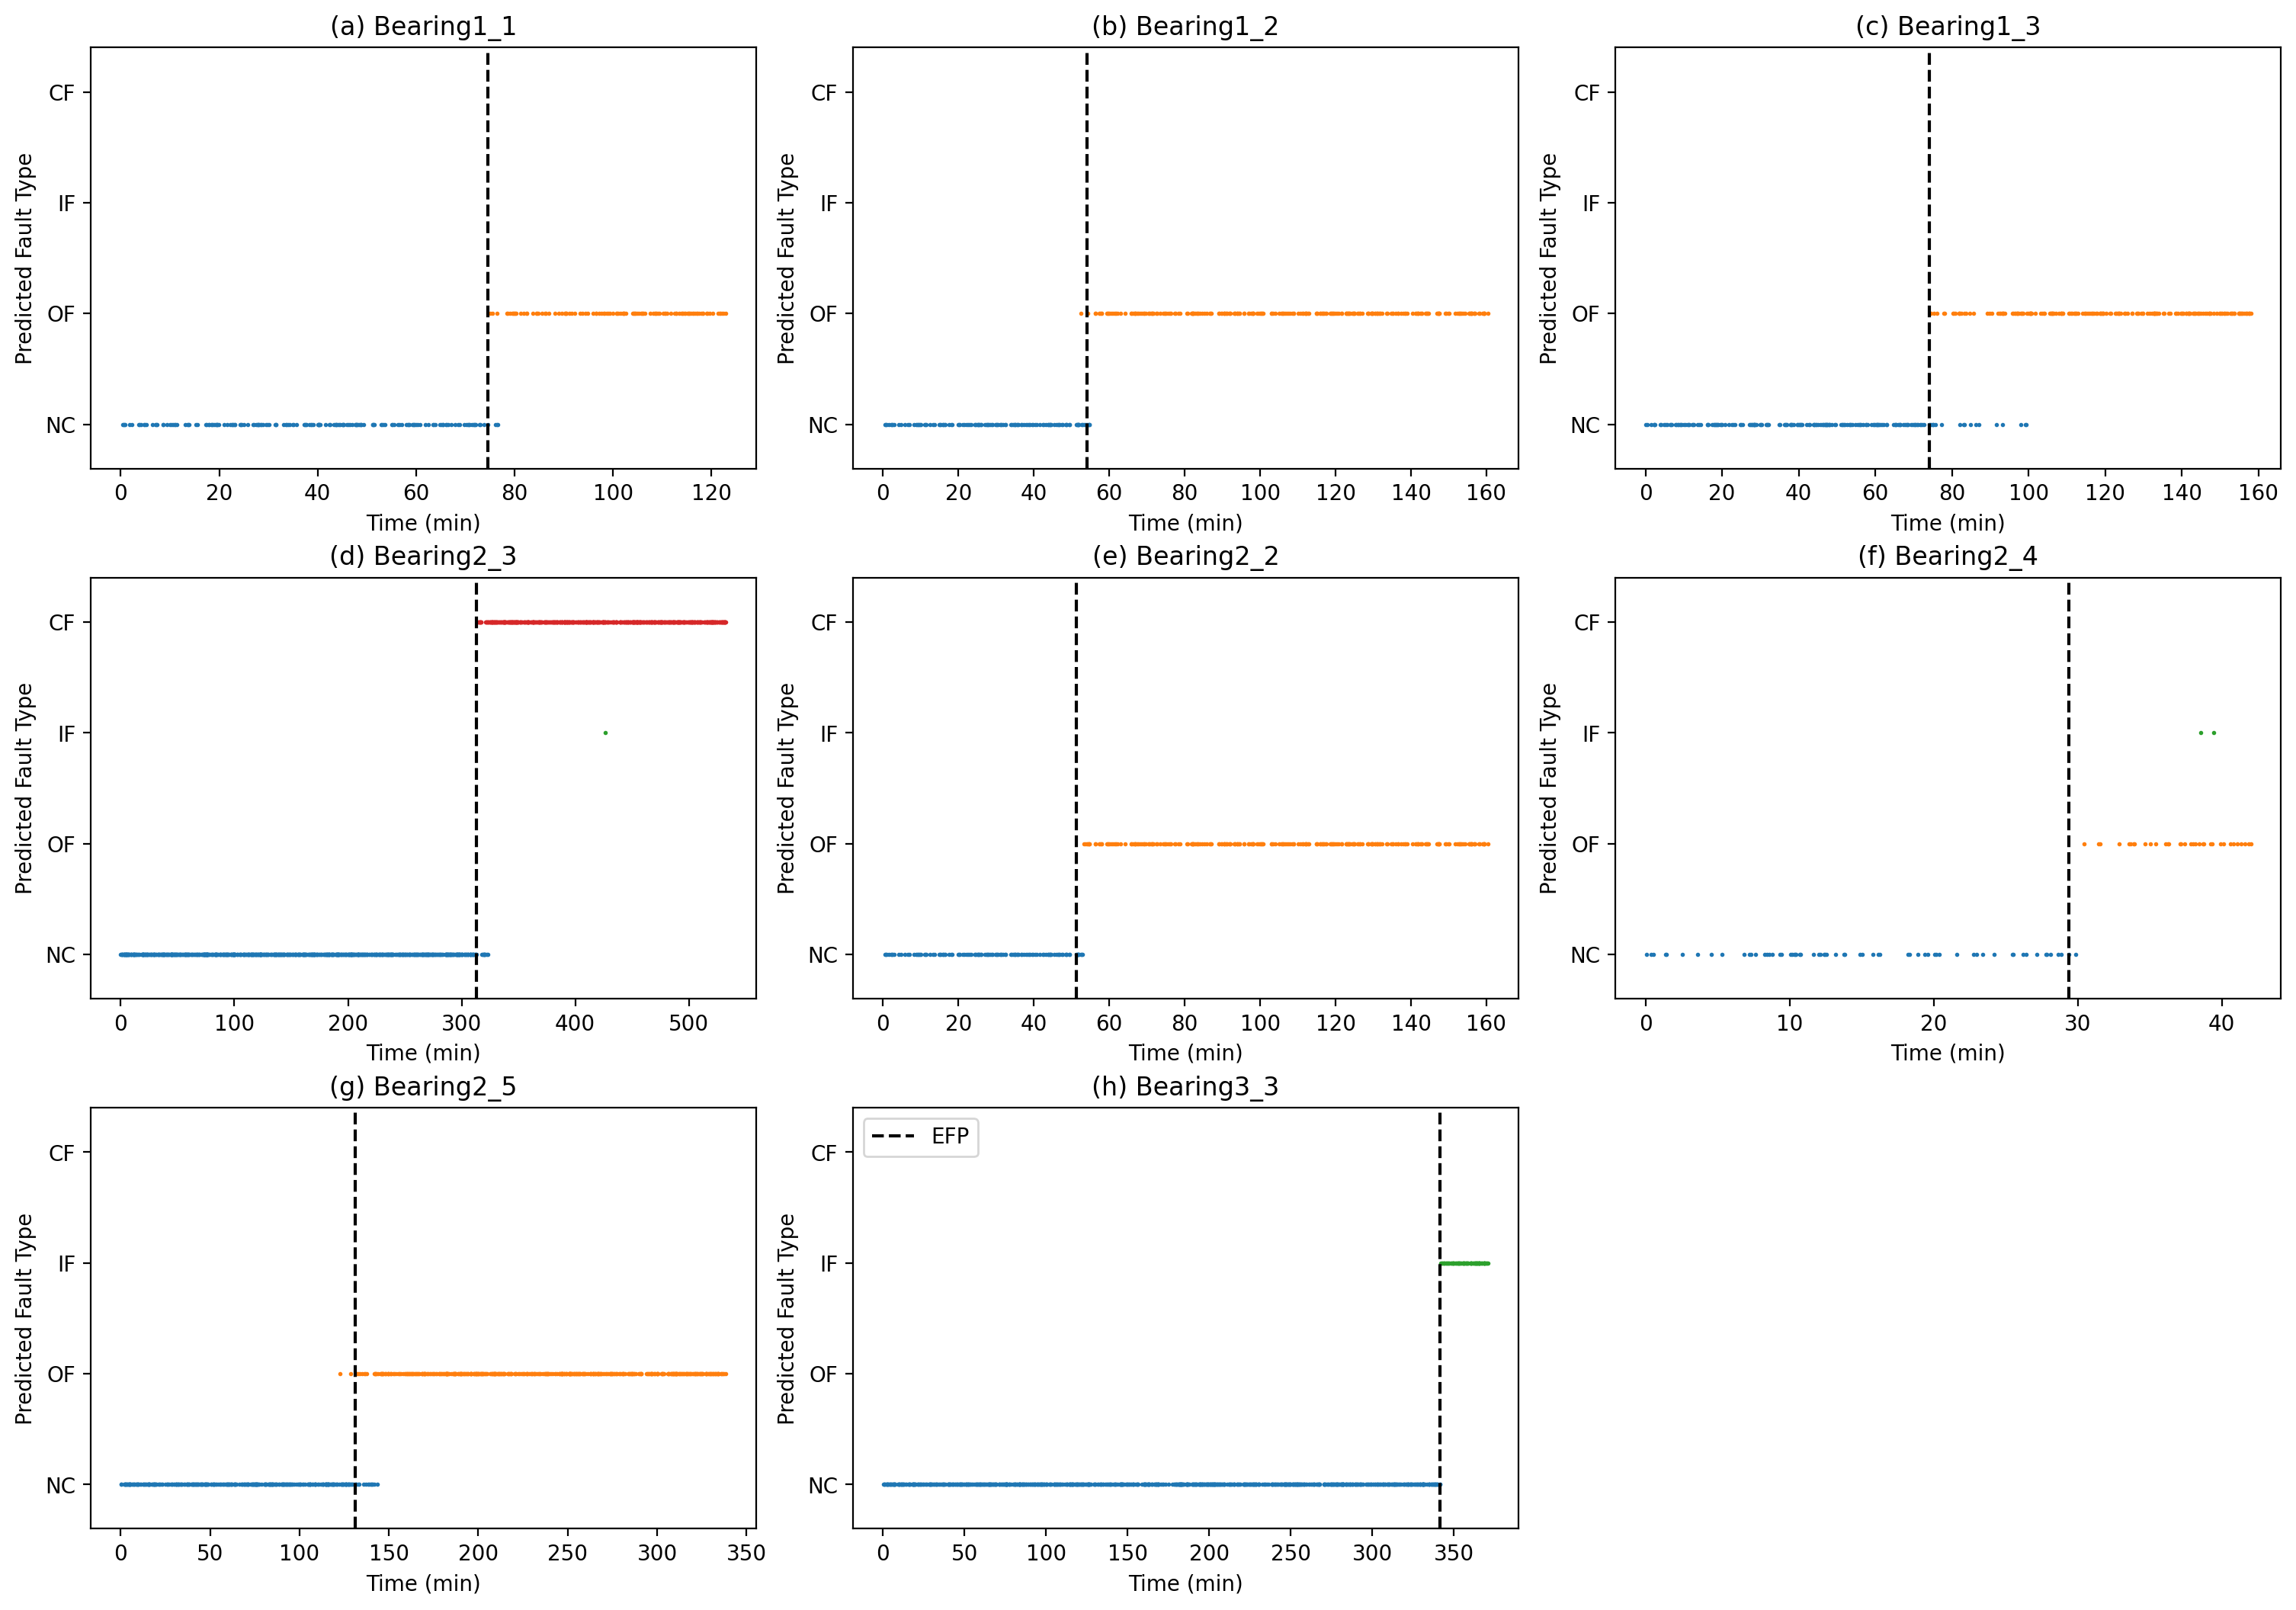

In [10]:
Plotter.fault_evolution(test_set, result, types=fault_types)

# 预测结果评价

In [11]:
evaluator = Evaluator()
evaluator.add(Accuracy(), WeightedF1Score())
evaluator(test_set, result)

ModuleNotFoundError: No module named 'sklearn'